In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from dataclasses import dataclass 
import math  

In [ ]:
class LayerNormalization(nn.Module):
    def __init__(self, model_dim):
        super().__init__()
        self.model_dim = model_dim
        self.gamma = nn.Parameter(torch.ones(self.model_dim))
        self.beta = nn.Parameter(torch.zeros(self.model_dim))
        self.eps = 1e-5

    def forward(self, x):
        B, T, D = x.shape
        x_centered = x - torch.mean(x, dim=-1, keepdim=True)
        x_var = torch.mean(x_centered**2, dim=-1, keepdim=True)
        output = x_centered/torch.sqrt(x_var + self.eps)
        return self.gamma * output + self.beta 
    
class Linear(nn.Module):
    def __init__(self, in_dim, out_dim, bias=False):
        super().__init__()

        #define w parameter, no bias for now
        #divide by math.sqrt(in_dim) to avoid bad parameter initialization
        self.W = nn.Parameter(torch.randn(in_dim, out_dim)/ math.sqrt(in_dim))
    
    def forward(self, x):
        return torch.matmul(x, self.W)

class GLU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        B, T, D1 = x.shape
        N = D1 // 2
        l_proj1 =  x[:,:, :N]
        l_proj2 = x[:, :, N:]

        return l_proj1 * torch.sigmoid(l_proj2)

def SoftMax(x, dim):

        #numerically stable softmax
        x_max, _ = torch.max(x, dim=dim, keepdim=True)       #values, indices
        x_scaled = x - x_max
        num = torch.exp(x_scaled)
        den = torch.sum(num, dim=dim, keepdim=True)
        return num / den

def CrossEntropy(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=-1, keepdim=True)
    predictions = log_probs[torch.arange(len(targets)), targets]
    loss = -predictions.mean()
    return loss

In [32]:
class MultiHeadAttention(nn.Module):
    def __init__(self, model_dim, num_heads, device, causal=False):
        super().__init__()
        self.model_dim = model_dim
        self.head_dim = model_dim // num_heads
        self.num_heads = num_heads
        self.device = device
        self.causal = causal

        self.q_proj = Linear(self.model_dim, self.model_dim, bias=False)
        self.k_proj = Linear(self.model_dim, self.model_dim, bias=False)
        self.v_proj = Linear(self.model_dim, self.model_dim, bias=False)

        self.o_proj = Linear(self.model_dim, self.model_dim, bias=False)

    def forward(self, x):
        B, T, D = x.shape
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-2, -1)) #B, H, T, T
        score = score/math.sqrt(self.head_dim)

        if self.causal:
            tril = torch.tril(torch.ones(T, T)).to(self.device)
            score = score.masked_fill(tril==0, float('-inf'))
        
        attn_score = SoftMax(score, dim=-1) #B, H, T, T
        attention = torch.matmul(attn_score, v) #B, H, T, D_h
        attention = attention.transpose(1, 2).contiguous().view(B, T, D) #B, T, D

        return self.o_proj(attention) #B, T, D

In [33]:
class TransformerBlock(nn.Module):
    def __init__(self, model_dim, num_heads, device, causal=True) :
        super().__init__()

        self.MHSA = MultiHeadAttention(model_dim, num_heads, device, causal=causal)
        self.layernorm1 = LayerNormalization(model_dim)
        self.layernorm2 = LayerNormalization(model_dim)

        self.FFN = nn.Sequential(   
                        Linear(model_dim, 4*model_dim, bias=False),
                        GLU(),
                        Linear(2*model_dim, model_dim, bias=False)
                    )
        
    def forward(self, x):
        x1 = x + self.MHSA(self.layernorm1(x))
        x2 = x1 + self.FFN(self.layernorm2(x1))
        return x2

In [ ]:
class ViT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.model_dim = cfg.model_dim
        self.num_heads = cfg.num_heads
        self.num_blocks = cfg.num_blocks
        self.num_patches = cfg.num_patches # H//P * W //P
        self.device = cfg.device
        self.patch_size = cfg.patch_size #P
        self.patch_dim = cfg.patch_dim   #C*P*P
        self.num_classes = cfg.num_classes

        #transformer blocks (non-causal for ViT — every token attends to every other)
        self.num_blocks = self.num_blocks
        self.blocks = nn.ModuleList([TransformerBlock(self.model_dim, self.num_heads, self.device, causal=False) for _ in range(self.num_blocks)])
        self.logit_proj = Linear(self.model_dim, cfg.num_classes, bias=False)

        #token and position embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, self.model_dim))
        self.x_proj = Linear(self.patch_dim, self.model_dim)
        self.pos_emb = nn.Embedding(self.num_patches+1, self.model_dim)


    def forward(self, x, targets):
        B, C, H, W = x.shape
    
        P = self.patch_size

        x = x.unfold(dimension=2, size=P, step=P)
        x = x.unfold(dimension=3, size=P, step=P)     #B, C, H/P, W/P, P, P
        x = x.permute(0, 2, 3, 1, 4, 5)         #B, H/P, W/P, C, P, P

        #reshape to [B, T, D]
        num_patches = H//P * W //P
        patch_dim = C*P*P
        x = x.reshape(B, num_patches, C, P, P).reshape(B, num_patches, patch_dim) #B, T, D
        x = self.x_proj(x)
       
        cls_token1 = self.cls_token.expand(B, 1, self.model_dim)
        x = torch.cat([cls_token1, x], dim=1)

        #add position embeddings 
        pos_emb = self.pos_emb(torch.arange(num_patches+1, device=x.device)) #T, D
        x = x + pos_emb 


        for i in range(self.num_blocks):
            x = self.blocks[i](x)
        
        cls_logit = x[:, 0, :]  #B, D
        logits = self.logit_proj(cls_logit) #B, C

        loss = CrossEntropy(logits, targets)

        return logits, loss

In [35]:
from typing import Tuple 

@dataclass
class ConfigParameters:
    patch_size: int
    patch_dim: int
    num_classes: int
    num_patches: int
    device: str
    model_dim: int=256
    num_heads: int=4
    batch_size: int=64
    num_blocks: int=2
    
   

@dataclass
class OptimParameter:
    lr: float=3e-4
    betas: Tuple=(0.9, 0.95)
    eps: float=1e-8

In [36]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import os

BASE_DIR = "./"
CIFAR_DIR = "../cifar10"
# Standard CIFAR-10 per-channel stats (computed on the training set).
MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
STD = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)


class CIFAR10(Dataset):
    def __init__(self, split="train", normalize=True, channels_first=True):
        root = "../cifar10"
        images = np.load(os.path.join(root, f"{split}_images.npy"))                                                      
        labels = np.load(os.path.join(root, f"{split}_labels.npy"))

        x = images.astype(np.float32) / 255.0
        if normalize:
            x = (x - MEAN) / STD
        if channels_first:
            x = x.transpose(0, 3, 1, 2)  # NHWC -> NCHW

        self.images = torch.from_numpy(np.ascontiguousarray(x))
        self.labels = torch.from_numpy(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


def get_loaders(batch_size=128, num_workers=0, **kwargs):
    train = CIFAR10(split="train", **kwargs)
    test = CIFAR10(split="test", **kwargs)
    train_loader = DataLoader(
        train, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True, drop_last=True,
    )
    test_loader = DataLoader(
        test, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )
    return train_loader, test_loader


In [37]:
device = torch.device("mps")
patch_size = 8
patch_dim = 192
num_patches = 16
num_classes = 10

cfg = ConfigParameters(patch_size=patch_size, patch_dim=patch_dim, num_patches=num_patches, num_classes=num_classes, device=device)
opt_cfg = OptimParameter()
model = ViT(cfg)

optimizer = torch.optim.AdamW(model.parameters(), opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps)

In [38]:
train_loader, val_loader = get_loaders(batch_size=cfg.batch_size)
len(train_loader), len(val_loader)

(781, 157)

In [39]:
model = model.to(device)
model.train()

step = 0
max_steps = 781*20
train_loss = []

while step < max_steps:
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        
        train_loss.append(loss.item())
        step += 1

        if step % 500 == 0:
            print(loss.item())
       
        if step >= max_steps:
            break

1.3490078449249268
1.8226572275161743
1.2519575357437134
1.331384539604187
0.9830955266952515
1.2398756742477417
1.1225719451904297
0.8223263025283813
1.0278759002685547
0.9789847135543823
0.5962291955947876
0.6123958826065063
0.81219482421875
0.6475783586502075
0.808663010597229
0.6120123863220215
0.6563547849655151
0.3077847957611084
0.2549290657043457
0.309658944606781
0.233539879322052
0.10962922126054764
0.2737836241722107
0.24954818189144135
0.12128135561943054
0.289439857006073
0.2405567467212677
0.31794118881225586
0.22835007309913635
0.2707722783088684
0.13730672001838684


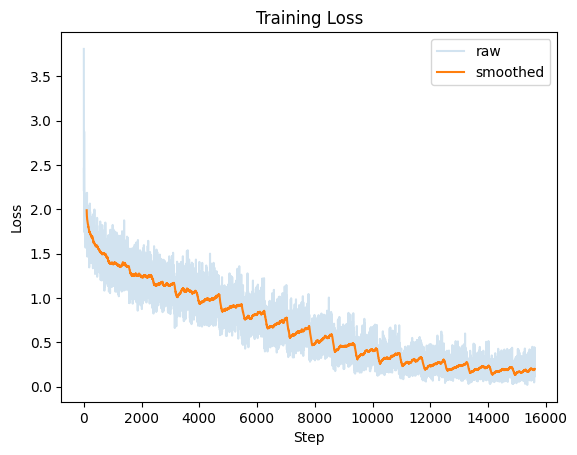

In [40]:
window = 100
smoothed = [
    sum(train_loss[i:i+window]) / window
    for i in range(len(train_loss) - window + 1)
]

import matplotlib.pyplot as plt
plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [41]:
def evaluate(model, dataloader, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            logits, loss = model(x, y)

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits, dim=1)   # [B]
            total_correct += (preds == y).sum().item()
            total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    model.train()
    return avg_loss, accuracy

In [42]:
val_loss, val_acc = evaluate(model, val_loader, device)

print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

/opt/miniconda3/envs/qwen/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Val Loss: 2.5748, Val Acc: 0.5434
